# ベクトル化された株式バックテストから、イベント駆動へ

セクション02は、シグナルにその後のリターンを掛けることで月次モメンタムを検証しました。
セクション04はここまで予測市場をリプレイしてきました。その間にあるのが、実務でいちばん
必要になるレシピです。すでに信じている株式戦略を、マッチングエンジンに通して、掛け算が
何を隠していたのかを確かめます。

ベクトル化された株式バックテストには、3つの前提が隠れています。シグナルを作った終値で
売買したこと。その終値で買えて、オファーを払っていないこと。17.4株を買ったこと。どれも
板にぶつかると残りません。しかも3つのうち2つは、損益を一方向にしか動かしません。

このレシピは2つのバックテストを1セント単位で突き合わせます。差はタイミング、スプレッド、
手数料に分解でき、残差はゼロであることをアサートします。問いは「どちらの数字を信じるか」
から、「この3つのどれに異議を唱えたいか」に変わります。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| ベクトル化バックテスト | 板を介さず、シグナル×その後のリターンとして損益を計算する形式 |
| バー | 始値・高値・安値・終値・出来高の1期間。ここでは1営業日 |
| 板（オーダーブック） | 注文が実際にぶつかる、指値の買いと売りの並び |
| ハーフスプレッド | ビッドとオファーの差の半分。1株あたりの発注コスト |
| 目標ポジション | 戦略が持ちたい株数。そこへ到達するための注文とは別物 |
| 形成日 | シグナルを作ったデータの日付 |
| 突き合わせ（リコンサイル） | 同じものの2つの計算の差を、1セント残らず説明すること |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import backtest, col, sql_expr, time_bucket
import cookbook_utils as cu

## 1. データ

大型株10銘柄の実際の日次バーです。Yahoo Finance から取得してキャッシュしてあります。
1営業日・1銘柄で1行です。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | 営業日 |
| `symbol` | `string` | ティッカー |
| `open`, `high`, `low`, `close` | `float64` | その日の価格 |
| `adj_close` | `float64` | 分割・配当調整後の終値 |
| `volume` | `int64` | 出来高 |

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES[:10], start="2020-01-01", end="2026-07-01")
print(f"{daily.num_rows:,} rows x {daily.num_columns} columns")
daily.to_pandas().head()

16,310 rows x 8 columns


,ts,symbol,open,high,low,close,adj_close,volume
0,2020-01-02 20:00:00+00:00,AAPL,74.059998,75.150002,73.797501,75.087502,72.333862,135480400
1,2020-01-02 20:00:00+00:00,JPM,139.789993,141.100006,139.259995,141.089996,117.899200,10803700
2,2020-01-02 20:00:00+00:00,MSFT,158.779999,160.729996,158.330002,160.619995,151.829529,22622100
3,2020-01-02 20:00:00+00:00,BRK-B,227.509995,228.389999,226.710007,228.389999,228.389999,3764000
4,2020-01-02 20:00:00+00:00,META,206.750000,209.789993,206.270004,209.779999,207.953842,12077100


## 2. バーデータに板は入っていない

エンジンは正規の `bars` テーブルを受け付け、バーは保有ポジションの評価に使う *mark* を
更新します。ただし板は作りません。バーだけの環境に届いた注文は流動性に出会わず、いつまでも
約定しません。これはエンジンの不足ではありません。日次バーには、そもそも何が提示されていたか
が記録されていないのです。

そこで板を仮定する必要があります。そして仮定は約定価格の中に隠さず、コードに書くべきです。
`cu.make_equity_market` はいちばん素直な仮定を作ります。各バーの終値を中心に `spread_bps`
の幅で両側に気配を置き、そのバーの出来高の一部を各サイドに表示します。

In [3]:
tape = daily.to_pandas()
tape = tape[tape["ts"] >= pd.Timestamp("2022-01-01", tz="UTC")]
tape = pa.Table.from_pandas(tape, preserve_index=False)
market = cu.make_equity_market(tape, spread_bps=5.0, depth_fraction=0.002)
for name, table in market.items():
    print(f"{name}: {table.num_rows:,} rows x {table.num_columns} columns")
market["book_deltas"].to_pandas().head(4)

instruments: 10 rows x 10 columns
bars: 11,260 rows x 10 columns
book_deltas: 22,520 rows x 11 columns
trades: 11,260 rows x 9 columns


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2022-01-03 20:00:00.000000,2022-01-03 20:00:00.000000,AAPL,0,snapshot,buy,181.9645,208975.8,0,False,cookbook-bars
1,2022-01-03 20:00:00.000000,2022-01-03 20:00:00.000000,AAPL,0,snapshot,sell,182.0555,208975.8,0,True,cookbook-bars
2,2022-01-03 20:00:00.000001,2022-01-03 20:00:00.000001,AMZN,0,snapshot,buy,170.3619,127040.0,1,False,cookbook-bars
3,2022-01-03 20:00:00.000001,2022-01-03 20:00:00.000001,AMZN,0,snapshot,sell,170.4471,127040.0,1,True,cookbook-bars


1つの `event_index` が1つのアトミックな板イベントです。ある瞬間の、ある銘柄のビッド行と
オファー行で、`is_last` が終わりを示します。エンジンは1イベントを最後まで読んでから、
注文にそれを見せます。

正規の時刻列は `ts_init` で、ナノ秒・タイムゾーンなしです。クックブックの他の場所にある
`ts` 列と見た目が違うのはそのためです。

In [4]:
db = h5i_db.Database(cu.fresh_db("04_equity_bars_to_event_driven"), create=True)
prices = daily.sort_by([("ts", "ascending"), ("symbol", "ascending")])
db.create_table("prices", prices.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices", prices, note="daily bars, 10 large caps")
for name in ("instruments", "book_deltas", "trades"):
    table = market[name]
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="book synthesized from bars at 5bp")
db.snapshot(
    "tape-5bp",
    tables=["prices", "instruments", "book_deltas", "trades"],
    note="Prices plus the 5bp synthetic book that every run here reads",
)
db.tables()

['book_deltas', 'instruments', 'prices', 'trades']

## 3. シグナルはエンジンの中で

月次グリッド上の古典的な12-1モメンタムです。12か月前から1か月前までのリターンなので、
直近1か月は飛ばします。月末終値は `last()` の集約で、2つのラグは月次フレーム上の
ウィンドウ関数なので、シグナル全体が1つのクエリになります。

In [5]:
monthly = (
    db.table("prices", snapshot="tape-5bp")
    .with_columns(month=time_bucket("1mo", col("ts")))
    .group_by("symbol", "month")
    .agg(close=col("close").last("ts"), formation_ts=col("ts").max())
    .with_columns(
        lag_1=sql_expr("lag(close, 1)").over(partition_by="symbol", order_by="month"),
        lag_12=sql_expr("lag(close, 12)").over(partition_by="symbol", order_by="month"),
    )
    .with_columns(momentum=col("lag_1") / col("lag_12") - 1)
    .filter(col("momentum").is_not_null())
    .sort(["month", "symbol"])
)
signal = monthly.to_pandas()
signal = signal[signal["formation_ts"] >= pd.Timestamp("2022-02-01", tz="UTC")]
print(f"{len(signal):,} symbol-months over {signal['month'].nunique()} rebalances")
signal.head()

530 symbol-months over 53 rebalances


,symbol,month,close,formation_ts,lag_1,lag_12,momentum
130,AAPL,2022-02-01 00:00:00+00:00,165.119995,2022-02-28 20:00:00+00:00,174.779999,121.260002,0.441366
131,AMZN,2022-02-01 00:00:00+00:00,153.563004,2022-02-28 20:00:00+00:00,149.573502,154.646500,-0.032804
132,BRK-B,2022-02-01 00:00:00+00:00,321.450012,2022-02-28 20:00:00+00:00,313.019989,240.509995,0.301484
133,GOOGL,2022-02-01 00:00:00+00:00,135.057007,2022-02-28 20:00:00+00:00,135.303497,101.095497,0.338373
134,JPM,2022-02-01 00:00:00+00:00,141.800003,2022-02-28 20:00:00+00:00,148.600006,147.169998,0.009717


## 4. 注文の前に目標

銘柄の選択とサイジングは10銘柄の日次計算なので、Python の担当です。毎月、モメンタム上位
3銘柄に固定の想定元本を等分し、整数株に切り下げます。それ以外はフラットです。

切り下げはここで1回だけ行い、以下のどのバックテストも同じ整数株数を売買します。4つの計算
すべてに共通する項は、その差を説明できません。

最後の2か月は落とします。それらの注文はテープの最終レコード以降に解放されることになり、
リプレイが到達しない注文は、ベクトル化版でも計上してよい売買ではありません。

In [6]:
CAPITAL = 300_000.0
TOP_N = 3

rows = []
for month, group in signal.groupby("month", sort=True):
    picks = group.nlargest(TOP_N, "momentum")
    formation = picks["formation_ts"].max()
    for pick in picks.itertuples():
        rows.append(
            {
                "formation_ts": formation,
                "symbol": pick.symbol,
                "shares": float(int(CAPITAL / TOP_N / pick.close)),
            }
        )
picked = pd.DataFrame(rows)
sessions = pd.DatetimeIndex(daily.to_pandas()["ts"].unique()).sort_values()
formation_index = sessions.searchsorted(picked["formation_ts"])
picked = picked[formation_index + 2 < len(sessions)]

grid = pd.MultiIndex.from_product(
    [sorted(picked["formation_ts"].unique()), sorted(picked["symbol"].unique())],
    names=["formation_ts", "symbol"],
)
positions = (
    picked.set_index(["formation_ts", "symbol"])
    .reindex(grid, fill_value=0.0)
    .reset_index()
    .sort_values(["formation_ts", "symbol"])
)
print(f"{len(positions):,} target rows over {positions['formation_ts'].nunique()} rebalances")
positions.head(6)

520 target rows over 52 rebalances


,formation_ts,symbol,shares
0,2022-02-28 20:00:00+00:00,AAPL,605.0
1,2022-02-28 20:00:00+00:00,AMZN,0.0
2,2022-02-28 20:00:00+00:00,BRK-B,0.0
3,2022-02-28 20:00:00+00:00,GOOGL,0.0
4,2022-02-28 20:00:00+00:00,JPM,0.0
5,2022-02-28 20:00:00+00:00,META,0.0


`backtest.target_positions` は、持ちたい残高を、そこへ到達する最小限の注文列に変えます。
銘柄ごとの現在ポジションはこの関数が自分で追跡します。同じ目標が続けば、注文は出ません。

決定的なのはタイムスタンプです。ある瞬間に解放された注文意図は、会場がすでに処理し終えた
最後の板にぶつかります。つまり **タイムスタンプが価格を選び**、約定は次のイベントで記録
されます。形成日の終値の1マイクロ秒後に押すと、形成日の終値で売買することになります。
このレシピが外そうとしている、まさにその前提です。

そこで各注文には、*翌営業日* の、その銘柄自身の気配の1マイクロ秒後を押します。月曜の終値で
決めて、火曜の気配が最新のときに送り、そこで約定する、という形です。形成日より後の情報は
判断に入りません。タイムスタンプは、判断がいつ市場に届いたかを言っているだけです。

`cu.make_equity_market` は同じ営業日の中で銘柄ごとに1マイクロ秒ずつずらすので、「その銘柄の
気配」は曖昧さのない1つの瞬間になります。ずらしがないと、同時刻イベントの束に解放された
注文は、マージが最初に到達した銘柄についてだけ新しい板に出会うことになります。

In [7]:
book = market["book_deltas"].to_pandas()
book["session"] = book["ts_init"].dt.floor("s").dt.tz_localize("UTC")
quote_at = {(row.session, row.instrument_id): row.ts_init for row in book.itertuples()}
touch_at = {
    (row.session, row.instrument_id, row.side): row.price for row in book.itertuples()
}
depth_at = {
    (row.session, row.instrument_id, row.side): row.size for row in book.itertuples()
}

positions["execution_ts"] = sessions[
    sessions.searchsorted(positions["formation_ts"], side="right")
]
stamps = [
    quote_at[(row.execution_ts, row.symbol)] + dt.timedelta(microseconds=1)
    for row in positions.itertuples()
]
signals = backtest.target_positions(
    stamps,
    positions["shares"].tolist(),
    instrument_id=positions["symbol"].tolist(),
    tag="momentum-12-1",
)
backtest.create_signal_table(db)
db.append("signals", signals, note="12-1 momentum, top 3, whole shares")

orders = signals.to_pandas()
orders["execution_session"] = pd.DatetimeIndex(orders["ts"]).tz_localize("UTC").floor("s")
orders["formation_session"] = sessions[
    sessions.searchsorted(orders["execution_session"]) - 1
]
print(f"{signals.num_rows:,} orders from {len(positions):,} targets")
orders.head()[["ts", "instrument_id", "side", "quantity", "formation_session"]]

182 orders from 520 targets


,ts,instrument_id,side,quantity,formation_session
0,2022-03-01 20:00:00.000001024,AAPL,buy,605.0,2022-02-28 20:00:00+00:00
1,2022-03-01 20:00:00.000008192,NVDA,buy,4100.0,2022-02-28 20:00:00+00:00
2,2022-03-01 20:00:00.000009984,XOM,buy,1275.0,2022-02-28 20:00:00+00:00
3,2022-04-01 20:00:00.000001024,AAPL,sell,33.0,2022-03-31 20:00:00+00:00
4,2022-04-01 20:00:00.000008192,NVDA,sell,436.0,2022-03-31 20:00:00+00:00


## 5. イベント駆動の実行

マーケットデータはスナップショットにピン留めし、手数料は比例で課金し、実行は自分のフォークに
書き込みます。戦略についてここで言い直すことは何もありません。戦略はテーブルそのものです。

In [8]:
FEE_RATE = 0.0005

report = backtest.run(
    db,
    "momentum-5bp",
    starting_cash=CAPITAL,
    signals="signals",
    snapshot="tape-5bp",
    fee_kind="proportional",
    fee_rate=FEE_RATE,
    equity_interval_nanos=86_400_000_000_000,
)
run_db = db.fork(report["fork"])
fills = run_db.read("bt_fills").to_pandas()
print(f"orders {report['orders']}  fills {report['fills']}  "
      f"commissions {report['commissions']:,.2f}")
print(f"final cash {report['final_cash']:,.2f}")
fills.head()

orders 182  fills 182  commissions 3,243.12
final cash 315,043.70


,ts,order_id,instrument_id,outcome,side,price,quantity,commission,is_taker,tag
0,2022-03-01 20:00:00.000002,1,AAPL,0,buy,163.2408,605.0,49.380342,True,momentum-12-1
1,2022-03-01 20:00:00.000009,2,NVDA,0,buy,23.4829,4100.0,48.139945,True,momentum-12-1
2,2022-03-02 20:00:00.000000,3,XOM,0,buy,79.1898,1275.0,50.483497,True,momentum-12-1
3,2022-04-01 20:00:00.000002,4,AAPL,0,sell,174.2664,33.0,2.875396,True,momentum-12-1
4,2022-04-01 20:00:00.000009,5,NVDA,0,sell,26.7053,436.0,5.821755,True,momentum-12-1


すべての注文が全量約定しました。これは戦略の性質というより、この板の性質です。残しておく
価値があるのは、各注文が実際に出会った厚みとの比較です。ここでいちばん大きい注文でも、
その瞬間に表示されていた数量の数パーセントです。これが大きな割合になると、約定価格は
最良気配ではなくなり、以下の突き合わせも成り立たなくなります。注文がその議論に負け始める
のがレシピ 04/10 です。

In [9]:
consumed = orders.apply(
    lambda order: order["quantity"]
    / depth_at[
        (
            order["execution_session"],
            order["instrument_id"],
            "sell" if order["side"] == "buy" else "buy",
        )
    ],
    axis=1,
)
assert len(fills) == report["orders"], "a partial fill would break the reconciliation"
assert consumed.max() < 1.0, "an order asked for more than the book showed"
print(f"orders filled in full     {len(fills)} of {report['orders']}")
print(f"largest order vs depth    {consumed.max():.1%}")
print(f"median order vs depth     {consumed.median():.1%}")

orders filled in full     182 of 182
largest order vs depth    6.6%
median order vs depth     0.1%


## 6. 同じ売買を、ベクトル化した3通りで

以下のどの計算も、同じ瞬間に同じ整数株数を売買します。変わるのは価格だけです。

1. **形成日の終値** — ベクトル化バックテストがふつう仮定する価格
2. **執行日の終値** — 翌営業日。注文を実際に出せたのはそこだから
3. **執行日の最良気配** — 仲値ではなく、ビッドまたはオファー

現金は直接追跡します。買えば現金が減り、売れば戻り、最後まで残った保有は最終終値で評価します。

In [10]:
closes = daily.to_pandas().pivot(index="ts", columns="symbol", values="close").sort_index()
close_at = closes.stack().to_dict()
orders.head(3)[["ts", "instrument_id", "side", "quantity", "execution_session"]]

,ts,instrument_id,side,quantity,execution_session
0,2022-03-01 20:00:00.000001024,AAPL,buy,605.0,2022-03-01 20:00:00+00:00
1,2022-03-01 20:00:00.000008192,NVDA,buy,4100.0,2022-03-01 20:00:00+00:00
2,2022-03-01 20:00:00.000009984,XOM,buy,1275.0,2022-03-01 20:00:00+00:00


価格をつける前に、どの板に各注文が出会ったのかについてエンジンと認識が合っているかを
確認します。どの約定も執行日の最良気配を持ち、記録は1営業日あとになるはずです。解放された
注文意図は最後に処理された板に約定し、次のイベントの時刻が押されるからです。

In [11]:
executions = fills.sort_values("order_id").reset_index(drop=True)
assert (executions["instrument_id"] == orders["instrument_id"]).all()
assert (executions["side"] == orders["side"]).all()
assert (executions["quantity"] == orders["quantity"]).all()

expected = [
    touch_at[(row.execution_session, row.instrument_id, "sell" if row.side == "buy" else "buy")]
    for row in orders.itertuples()
]
recorded = pd.DatetimeIndex(executions["ts"]).tz_localize("UTC")
assert (executions["price"] - expected).abs().max() < 1e-9, "a fill missed the touch"
assert (recorded > orders["execution_session"]).all(), "a fill was recorded too early"
print(f"all {len(orders)} fills took the touch of their execution session,")
print("and every one was recorded at the following session")

all 182 fills took the touch of their execution session,
and every one was recorded at the following session


In [12]:
def ending_equity(price_of) -> float:
    """Ending equity from the order sequence, priced by `price_of`."""
    cash, held = CAPITAL, {}
    for order in orders.itertuples():
        signed = order.quantity if order.side == "buy" else -order.quantity
        cash -= signed * price_of(order)
        held[order.instrument_id] = held.get(order.instrument_id, 0.0) + signed
    return cash + sum(
        quantity * close_at[(sessions[-1], name)] for name, quantity in held.items()
    )


formation_close = ending_equity(
    lambda o: close_at[(o.formation_session, o.instrument_id)]
)
execution_close = ending_equity(
    lambda o: close_at[(o.execution_session, o.instrument_id)]
)
execution_touch = ending_equity(
    lambda o: touch_at[
        (o.execution_session, o.instrument_id, "sell" if o.side == "buy" else "buy")
    ]
)
for label, value in (
    ("formation close", formation_close),
    ("execution close", execution_close),
    ("execution touch", execution_touch),
):
    print(f"{label:<18} {value:>14,.2f}")

formation close        603,366.52
execution close        602,252.92
execution touch        600,623.68


## 7. 突き合わせ

実行の最終エクイティは、最終現金に、まだ持っている分を同じ最終終値で評価した額を足したもの
です。ベクトル化の答えからその数字までの各ステップには名前がついていて、残差は目視で済ませず
アサートで確認します。

In [13]:
holdings = run_db.read("bt_positions").to_pandas()
event_driven = float(report["final_cash"]) + sum(
    row.quantity * close_at[(sessions[-1], row.instrument_id)]
    for row in holdings.itertuples()
)

waterfall = pd.DataFrame(
    [
        {"step": "vectorized (formation close)", "equity": formation_close, "delta": 0.0},
        {"step": "timing: trade the next close", "equity": execution_close,
         "delta": execution_close - formation_close},
        {"step": "spread: pay the touch", "equity": execution_touch,
         "delta": execution_touch - execution_close},
        {"step": "fees: proportional commission",
         "equity": execution_touch - report["commissions"],
         "delta": -report["commissions"]},
        {"step": "event-driven run", "equity": event_driven,
         "delta": event_driven - (execution_touch - report["commissions"])},
    ]
)
residual = waterfall["delta"].iloc[-1]
assert abs(residual) < 0.05, f"unexplained {residual:,.4f}"
waterfall.round(2)

,step,equity,delta
0,vectorized (formation close),603366.52,0.00
1,timing: trade the next close,602252.92,-1113.61
2,spread: pay the touch,600623.68,-1629.24
3,fees: proportional commission,597380.57,-3243.12
4,event-driven run,597380.57,-0.00


残差は1セント単位でゼロです。これが主張する価値のあることです。2つのバックテストの差は
ノイズでもエンジンの都合でもなく、3つの判断であり、それぞれについて擁護も変更もできます。

最初のステップの符号に注目してください。1日遅れて売買することは、構造的にコストではありません。
終値で作ったモメンタムのシグナルは、その分を返しにかかる銘柄を追いかけていることが多いのです。
スプレッドと手数料は一方向ですが、タイミングは違います。1つにまとめた数字では、自分がどちらの
リスクを取っているのかが分かりません。

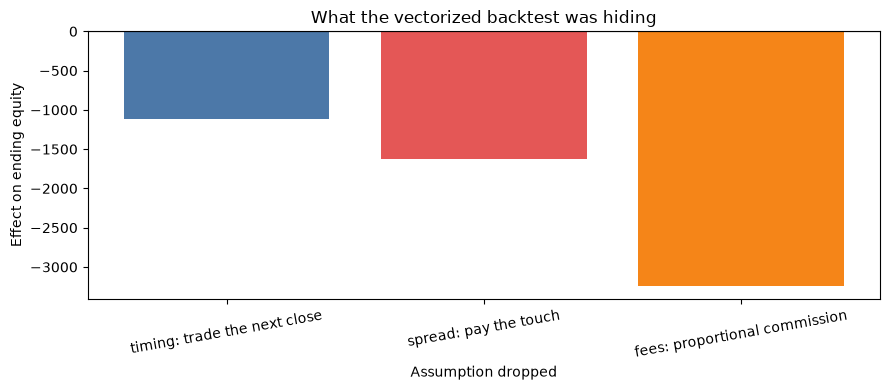

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
steps = waterfall.iloc[1:-1]
ax.bar(steps["step"], steps["delta"], color=["#4c78a8", "#e45756", "#f58518"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("What the vectorized backtest was hiding")
ax.set_xlabel("Assumption dropped")
ax.set_ylabel("Effect on ending equity")
ax.tick_params(axis="x", labelrotation=10)
fig.tight_layout()

## 8. スプレッドは推測だったのだから、動かしてみる

`spread_bps` は測った値ではありません。選んだ値です。ですからそれに依存する結論は、推測についての
結論です。仮定ごとに板を作り直して取り込めば、感度がそのまま得られます。レシピ 04/11 は、
この推測を約定そのものから推定した数字に置き換えます。

In [15]:
trials = []
for spread_bps in (1.0, 5.0, 20.0, 50.0):
    scenario = cu.make_equity_market(tape, spread_bps=spread_bps, depth_fraction=0.002)
    trial = h5i_db.Database(cu.fresh_db(f"04_equity_spread_{int(spread_bps)}"), create=True)
    for name in ("instruments", "book_deltas", "trades"):
        table = scenario[name]
        trial.create_table(name, table.schema, time_column="ts_init")
        trial.append(name, table)
    trial.snapshot("tape", tables=["instruments", "book_deltas", "trades"])
    backtest.create_signal_table(trial)
    trial.append("signals", signals)
    trial_report = backtest.run(
        trial,
        f"momentum-{int(spread_bps)}bp",
        starting_cash=CAPITAL,
        signals="signals",
        snapshot="tape",
        fee_kind="proportional",
        fee_rate=FEE_RATE,
        equity_interval_nanos=86_400_000_000_000,
    )
    trial_fork = trial.fork(trial_report["fork"])
    still_held = trial_fork.read("bt_positions").to_pandas()
    ending = float(trial_report["final_cash"]) + sum(
        row.quantity * close_at[(sessions[-1], row.instrument_id)]
        for row in still_held.itertuples()
    )
    trials.append(
        {
            "spread_bps": spread_bps,
            "ending_equity": ending,
            "return_pct": 100 * (ending / CAPITAL - 1),
            "commissions": trial_report["commissions"],
        }
    )
    trial_fork.close()
    trial.close()
sensitivity = pd.DataFrame(trials)
sensitivity.round(2)

,spread_bps,ending_equity,return_pct,commissions
0,1.0,598615.64,99.54,3243.12
1,5.0,597380.57,99.13,3243.12
2,20.0,592523.38,97.51,3243.11
3,50.0,582794.21,94.26,3243.10


仮定した5ベーシスポイントでは、スプレッドのコストは手数料の請求額のおよそ半分です。この
仮定を50ベーシスポイントに動かすと、手数料の総額の数倍になり、ベンチマークに対する戦略の
順位まで変わりえます。ベクトル化バックテストが明示しなくても済んでしまう数字です。

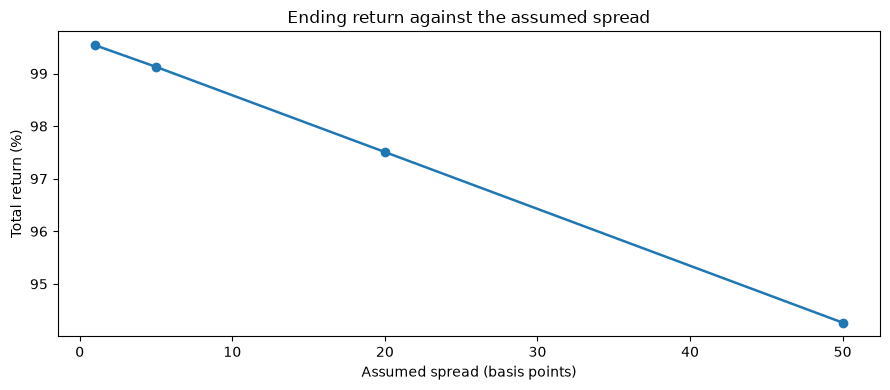

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sensitivity["spread_bps"], sensitivity["return_pct"], marker="o", linewidth=1.8)
ax.set_title("Ending return against the assumed spread")
ax.set_xlabel("Assumed spread (basis points)")
ax.set_ylabel("Total return (%)")
fig.tight_layout()

## まとめ

- バーは mark を更新するだけで、板を作りません。イベント駆動の株式バックテストには板が
  必要で、その仮定をデータとして書くことで、議論の対象にできます。
- `backtest.target_positions` は、リサーチのポジションベクトルから注文意図への橋渡しで、
  状態を変える注文だけを出します。
- タイムスタンプが価格を選びます。注文意図は処理済みの最後の板に約定し、記録は次のイベント
  です。*翌営業日* の気配のあとに押すことが、その日の終値で執行することにあたり、
  先読みもありません。
- ベクトル化とイベント駆動の差は、タイミング・スプレッド・手数料に分解でき、残差は目視では
  なくアサートすべきです。
- タイミングは有利にも不利にも働き、スプレッドと手数料は不利にしか働きません。1つにまとめた
  数字は、そのどちらを取っているのかを隠します。
- 名前付きスナップショットが価格と合成した板をまとめてピン留めするので、このレシピのどの
  実行も同じバイト列を読みます。

In [17]:
run_db.close()
db.close()